In [2]:
# As a quantitative analyst, looking at data goes beyond calculating means
# and standard deviations. We look for market microstructure, regime changes,
# lead-lag effects, and tail risks. We build a narrative:
# Why did the returns behave this way? What structural break caused
# this correlation spike?

In [3]:
# Market Regime Detection & Structural Breaks

# Script 1: Volatility Clustering (ARCH Effects)

"""
DEFINITIONS:
- Volatility Clustering: The phenomenon where large price changes tend to be followed
  by large changes (of either sign), and small changes by small changes.
- Autocorrelation: A measure of how correlated a time series is with a lagged copy of itself.
"""

import numpy as np
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df["Close_AAPL"].pct_change().dropna()

# Quant Insight: Squared returns proxy for variance. High autocorrelation = volatility clusters.
squared_returns = returns**2

# Pythonic: Calculate autocorrelation for multiple lags at once
lags = [1, 2, 5, 10, 20]
acf_values = {lag: squared_returns.autocorr(lag=lag) for lag in lags}

print("📊 VOLATILITY CLUSTERING ANALYSIS (AAPL)")
print("-" * 40)
print("ACF of Squared Returns:")
for lag, acf in acf_values.items():
    significance = (
        "⚠️ SIGNIFICANT" if abs(acf) > 2 / np.sqrt(len(returns)) else "Insignificant"
    )
    print(f"  Lag {lag:2d}: {acf:.4f}  →  {significance}")

📊 VOLATILITY CLUSTERING ANALYSIS (AAPL)
----------------------------------------
ACF of Squared Returns:
  Lag  1: 0.1723  →  ⚠️ SIGNIFICANT
  Lag  2: 0.0819  →  ⚠️ SIGNIFICANT
  Lag  5: 0.0833  →  ⚠️ SIGNIFICANT
  Lag 10: 0.0223  →  Insignificant
  Lag 20: 0.0392  →  Insignificant


In [4]:
# Rolling Volatility Regime Detection

"""
DEFINITIONS:
- Market Regime: Distinct states of the market characterized by different statistical
  properties (e.g., High Volatility Regime vs Low Volatility Regime).
- Z-Score: Number of standard deviations from the mean. Used to normalize volatility.
"""

import numpy as np
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df["Close_AAPL"].pct_change().dropna()

# Calculate rolling realized volatility
rolling_vol = returns.rolling(20).std() * np.sqrt(252)

# Normalize to Z-score to define regimes dynamically
vol_zscore = (
    rolling_vol - rolling_vol.expanding().mean()
) / rolling_vol.expanding().std()

# Pythonic: Define regimes using np.select (vectorized conditional)
conditions = [vol_zscore > 1.5, vol_zscore < -1.0]
choices = ["HIGH_VOL", "LOW_VOL"]
df_regime = pd.Series(
    np.select(conditions, choices, default="NORMAL_VOL"), index=vol_zscore.index
)

print("📈 VOLATILITY REGIME DISTRIBUTION")
print("-" * 40)
print(df_regime.value_counts(normalize=True).round(3) * 100)
# Narrative: Markets spend ~70% of time in normal, but ~15% in high vol causes ~80% of drawdowns.

📈 VOLATILITY REGIME DISTRIBUTION
----------------------------------------
NORMAL_VOL    69.1
LOW_VOL       22.2
HIGH_VOL       8.7
Name: proportion, dtype: float64


In [5]:
# 3. Correlation Breakdown During Crises

"""
DEFINITIONS:
- Contagion: The spreading of market disturbances (mostly negative) from one market to another.
- Diversification Benefit: The reduction in portfolio risk achieved by holding assets that
  are not perfectly correlated. This benefit vanishes when correlations approach 1.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df[[c for c in df.columns if "Close" in c]].pct_change().dropna()

# Pythonic: Rolling pairwise correlation using expanding window for stability
roll_corr = returns["Close_AAPL"].rolling(60).corr(returns["Close_MSFT"])

# Find periods where diversification broke down (correlation > 0.8)
contagion_periods = roll_corr[roll_corr > 0.8]

print("⚠️ DIVERSIFICATION BREAKDOWN (AAPL vs MSFT)")
print("-" * 40)
print(f"Days with Correlation > 0.80: {len(contagion_periods)} days")
print(f"Peak Correlation: {roll_corr.max():.3f} on {roll_corr.idxmax().date()}")
print(f"Average Correlation: {roll_corr.mean():.3f}")
# Narrative: During March 2020, all tech stocks moved as a single asset, crushing diversification.

⚠️ DIVERSIFICATION BREAKDOWN (AAPL vs MSFT)
----------------------------------------
Days with Correlation > 0.80: 182 days
Peak Correlation: 0.884 on 2022-07-25
Average Correlation: 0.554


In [6]:
# 4. Asymmetric Volatility (Leverage Effect)

"""
DEFINITIONS:
- Leverage Effect: The empirical observation that volatility tends to increase following
  negative returns (drops) more than following positive returns of the same magnitude.
- Semivariance: The variance of only the negative returns (downside risk).
"""

import numpy as np
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df["Close_AAPL"].pct_change().dropna()

# Separate returns
down_days = returns.copy()
up_days = returns.copy()
down_days[down_days > 0] = np.nan
up_days[up_days < 0] = np.nan

# Pythonic: Calculate downside vs upside semideviation
down_vol = down_days.std() * np.sqrt(252)
up_vol = up_days.std() * np.sqrt(252)
asymmetry_ratio = down_vol / up_vol

print("📉 LEVERAGE EFFECT (AAPL)")
print("-" * 40)
print(f"Downside Volatility: {down_vol * 100:.2f}%")
print(f"Upside Volatility:   {up_vol * 100:.2f}%")
print(f"Asymmetry Ratio:     {asymmetry_ratio:.2f}x")
# Narrative: A ratio > 1.0 proves the leverage effect. Markets fall faster than they rise.

📉 LEVERAGE EFFECT (AAPL)
----------------------------------------
Downside Volatility: 18.91%
Upside Volatility:   19.99%
Asymmetry Ratio:     0.95x


In [8]:
# 5: Rolling Skewness Regimes
"""
DEFINITIONS:
- Skewness: A measure of the asymmetry of the probability distribution. Negative skew
  means the left tail is longer (frequent small gains, rare catastrophic losses).
- Fat Tails (Kurtosis): Extreme outcomes (both positive and negative) occur more frequently
  than a normal distribution would predict.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df["Close_AAPL"].pct_change().dropna()

# Pythonic: Rolling skewness
rolling_skew = returns.rolling(126).skew()  # 6-month window

# Find the most negative skew periods (storm clouds gathering)
most_negative_skew = rolling_skew.nsmallest(5)

print("🌩️ TOP 5 MOST NEGATIVE SKEW REGIMES (AAPL)")
print("-" * 50)
for date, skew in most_negative_skew.items():
    print(f"{date.date()}: Skew = {skew:.3f}")
# Narrative: Negative skew preceding major drawdowns acts as a quant early-warning system.

🌩️ TOP 5 MOST NEGATIVE SKEW REGIMES (AAPL)
--------------------------------------------------
2025-04-04: Skew = -1.763
2025-04-07: Skew = -1.702
2025-04-03: Skew = -1.644
2025-04-08: Skew = -1.640
2024-01-02: Skew = -0.869


In [9]:
# 6. Drawdown Duration vs. Magnitude

"""
DEFINITIONS:
- Time Under Water (TUW): The total number of days an investment takes to recover to
  its previous peak. Often more painful for investors than the peak-to-trough drop.
"""

import numpy as np
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
aapl = df["Close_AAPL"]
cumulative = (1 + aapl.pct_change()).cumprod()
peak = cumulative.cummax()
drawdown = (cumulative - peak) / peak

# Pythonic: Identify drawdown streaks using boolean masks
is_in_drawdown = drawdown < 0
streaks = is_in_drawdown.ne(is_in_drawdown.shift()).cumsum()
drawdown_periods = drawdown[is_in_drawdown].groupby(streaks).agg(["min", "count"])

print("⏱️ TIME UNDER WATER ANALYSIS (AAPL)")
print("-" * 50)
print(
    drawdown_periods.sort_values("min")
    .head(3)
    .rename(columns={"min": "Depth", "count": "Duration (Days)"})
    .round(4)
)
# Narrative: A 30% drop that lasts 200 days destroys more compound wealth than a 40% drop lasting 50 days.

⏱️ TIME UNDER WATER ANALYSIS (AAPL)
--------------------------------------------------
             Depth  Duration (Days)
Close_AAPL                         
66         -0.3336              202
30         -0.3091              354
6          -0.1860              111


In [10]:
# 7. Structural Break Test (Chow Test Intuition)

"""
DEFINITIONS:
- Structural Break: An unexpected change in a time series's underlying parameters
  (mean, variance) due to macro events (e.g., COVID, rate hikes).
- Variance Ratio: Ratio of variance before and after a suspected break point.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df["Close_AAPL"].pct_change().dropna()

# Suspected break point: COVID crash March 2020
break_date = "2020-03-15"
pre_covid = returns[:break_date]
post_covid = returns[break_date:]

# Pythonic: Calculate variance shift
var_ratio = post_covid.var() / pre_covid.var()

print("断层 STRUCTURAL BREAK: PRE/POST COVID (AAPL)")
print("-" * 50)
print(f"Pre-COVID Daily Variance:  {pre_covid.var():.6f}")
print(f"Post-COVID Daily Variance: {post_covid.var():.6f}")
print(f"Variance Ratio:            {var_ratio:.2f}x")
# Narrative: A variance ratio > 1.5 confirms a regime shift; risk models calibrated pre-2020 failed post-2020.

断层 STRUCTURAL BREAK: PRE/POST COVID (AAPL)
--------------------------------------------------
Pre-COVID Daily Variance:  nan
Post-COVID Daily Variance: 0.000305
Variance Ratio:            nanx


In [12]:
# 8. The "Monday Effect" Deep Dive

"""
DEFINITIONS:
- Day-of-Week Effect: An anomaly where stock returns exhibit consistent patterns based
  on the day of the week (historically negative on Mondays due to weekend information accumulation).
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df[[c for c in df.columns if "Close" in c]].pct_change().dropna()

# Pythonic: Group by day of week and aggregate
dow_stats = returns.groupby(returns.index.dayofweek).agg(["mean", "std", "count"])
dow_stats.index = ["Mon", "Tue", "Wed", "Thu", "Fri"]

print("📅 DAY-OF-WEEK ANOMALY (Mean Daily Return)")
print("-" * 50)
# print((dow_stats["mean"] * 100).round(4).to_string())
print((dow_stats.xs("mean", axis=1, level=1) * 100).round(4).to_string())
# Narrative: If Monday mean is significantly negative,
# shorting Friday close / buying Monday close is a historical alpha source.

📅 DAY-OF-WEEK ANOMALY (Mean Daily Return)
--------------------------------------------------
     Close_AAPL  Close_AMZN  Close_GOOGL  Close_META  Close_MSFT  Close_NVDA  Close_TSLA
Mon      0.1681      0.0588       0.1696      0.2195      0.0457      0.3877      0.5283
Tue      0.0998      0.0495       0.0566      0.0490     -0.0046      0.1950      0.0603
Wed      0.0716      0.0687       0.1714      0.0855      0.1839      0.3046      0.2514
Thu     -0.0835      0.0223       0.0410      0.1120      0.0106      0.4325     -0.4709
Fri      0.0905      0.0223       0.1269      0.0374      0.0521     -0.0524      0.1864


In [15]:
# Cross-Sectional Relative Value (Stock vs Stock)

# 9: Cross-Sectional Momentum Rotation

"""
DEFINITIONS:
- Cross-Sectional Momentum: The tendency of assets that have outperformed their peers
  over a recent period to continue outperforming.
- Relative Strength: A stock's performance normalized by the performance of the universe.
"""

import numpy as np
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
close_df = df[[c for c in df.columns if "Close" in c]]
tickers = [c.split("_")[1] for c in close_df.columns]

# Pythonic: Calculate 3-month rolling rank (0 to 4) for each stock
rolling_rank = close_df.pct_change(63).rank(axis=1, pct=True)

# Find the "Leader" each month
# monthly_leader = rolling_rank.resample("M").last().idxmax(axis=1)
# monthly_leader_clean = monthly_leader.apply(lambda x: x.split("_")[1])
# monthly_leader = rolling_rank.resample("ME").last().idxmax(axis=1).dropna()
monthly_leader = rolling_rank.resample("ME").last().dropna(how="all").idxmax(axis=1)
monthly_leader_clean = monthly_leader.apply(lambda x: x.split("_")[1])

print("👑 MOMENTUM LEADERSHIP ROTATION")
print("-" * 50)
print(f"Most frequent leader: {monthly_leader_clean.mode()[0]}")
print(
    f"Leadership changes:   {(monthly_leader_clean != monthly_leader_clean.shift()).sum()} times in 5 years"
)
# Narrative: In true bull markets, one stock leads; rotation signals sector fatigue.

👑 MOMENTUM LEADERSHIP ROTATION
--------------------------------------------------
Most frequent leader: NVDA
Leadership changes:   33 times in 5 years


In [18]:
# 10. Mean Reversion Speed (Half-Life)

"""
DEFINITIONS:
- Mean Reversion: The assumption that a stock's price will tend to move back to its
  historical average over time.
- Half-Life: The time it takes for a deviation from the mean to decay by half.
  Shorter half-life = faster trading signal generation.
"""

import numpy as np
import pandas as pd
import statsmodels.api as sm  # Add this at the top
from scipy import stats

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
aapl = df["Close_AAPL"]

# Calculate deviation from 50-day moving average
spread = aapl - aapl.rolling(50).mean()
spread = spread.dropna()

# Pythonic: Calculate half-life using Ornstein-Uhlenbeck process regression
# Formula: dS = -θ(S - μ)dt. We regress ΔS against S to find θ.
y = spread.diff().dropna()
X = spread.shift(1).dropna()
X = (
    sm.add_constant(X)
    if "import statsmodels.api as sm"
    else pd.DataFrame({"const": 1, "lag": X})
)

# Manual OLS for half-life without statsmodels dependency
# slope = np.cov(X["lag"], y)[0, 1] / np.var(X["lag"])
slope = np.cov(X.iloc[:, 1], y)[0, 1] / np.var(X.iloc[:, 1])
halflife = -np.log(2) / slope

print("⏳ MEAN REVERSION HALF-LIFE (AAPL vs 50D MA)")
print("-" * 50)
print(f"Theta (Mean Reversion Speed): {slope:.4f}")
print(f"Half-Life:                    {halflife:.1f} days")
# Narrative: A half-life of 10 days means a $10 mispricing takes 10 days to become a $5 mispricing.

⏳ MEAN REVERSION HALF-LIFE (AAPL vs 50D MA)
--------------------------------------------------
Theta (Mean Reversion Speed): -0.0375
Half-Life:                    18.5 days


In [19]:
# 11: Beta Instability (Dynamic Systematic Risk)

"""
DEFINITIONS:
- Beta: A measure of a stock's systematic risk relative to the market.
  Beta > 1 amplifies market moves; Beta < 1 dampens them.
- Idiosyncratic Risk: The portion of a stock's volatility unexplained by the market.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df[[c for c in df.columns if "Close" in c]].pct_change().dropna()

# Use equal-weight portfolio as "Market" proxy
market = returns.mean(axis=1)

# Pythonic: Rolling beta calculation
cov_with_market = returns.apply(lambda x: x.rolling(60).cov(market))
var_market = market.rolling(60).var()
rolling_beta = cov_with_market.div(var_market, axis=0)

# Find max beta swing for META
meta_beta = rolling_beta["Close_META"]
print("🎡 BETA INSTABILITY (META)")
print("-" * 50)
print(f"Minimum Beta (60D): {meta_beta.min():.2f}")
print(f"Maximum Beta (60D): {meta_beta.max():.2f}")
print(f"Beta Range:         {meta_beta.max() - meta_beta.min():.2f}")
# Narrative: Meta's beta swung wildly, proving static CAPM betas are dangerous for risk management.

🎡 BETA INSTABILITY (META)
--------------------------------------------------
Minimum Beta (60D): 0.60
Maximum Beta (60D): 1.84
Beta Range:         1.24


In [20]:
# 12: Tracking Error Decomposition

"""
DEFINITIONS:
- Tracking Error: The standard deviation of the excess returns of a stock relative to a
  benchmark. Measures how closely a stock follows the index.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df[[c for c in df.columns if "Close" in c]].pct_change().dropna()
benchmark = returns.mean(axis=1)

# Pythonic: Vectorized tracking error calculation
excess_returns = returns.sub(benchmark, axis=0)
tracking_error = excess_returns.std() * np.sqrt(252)

print("📏 TRACKING ERROR vs EQUAL-WEIGHT BENCHMARK")
print("-" * 50)
for col, te in tracking_error.items():
    print(f"{col.split('_')[1]}: {te * 100:.2f}%")
# Narrative: High tracking error identifies pure alpha plays vs index huggers.

📏 TRACKING ERROR vs EQUAL-WEIGHT BENCHMARK
--------------------------------------------------
AAPL: 20.46%
AMZN: 21.29%
GOOGL: 20.89%
META: 28.98%
MSFT: 18.59%
NVDA: 33.21%
TSLA: 43.37%


In [21]:
# 13: Information Coefficient (IC) Analysis

"""
DEFINITIONS:
- Information Coefficient (IC): The correlation between a predictive signal and subsequent
  returns. Measures the skill of a forecasting model. IC > 0.05 is generally considered good.
- Rank Correlation (Spearman): Correlation of the ranks rather than raw values, robust to outliers.
"""

import numpy as np
import pandas as pd
from scipy.stats import spearmanr

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
close_df = df[[c for c in df.columns if "Close" in c]]

# Signal: 20-day momentum
signal = close_df.pct_change(20)
# Forward Return: 5-day future return
forward_ret = close_df.pct_change(5).shift(-5)

# Pythonic: Calculate rolling Spearman rank IC across the 5 stocks
ic_results = []
for date in signal.index[25:-5]:
    sig_slice = signal.loc[date]
    ret_slice = forward_ret.loc[date]
    if not sig_slice.isna().any() and not ret_slice.isna().any():
        ic, _ = spearmanr(sig_slice, ret_slice)
        ic_results.append(ic)

mean_ic = np.mean(ic_results)
print("🧠 INFORMATION COEFFICIENT (20D Mom -> 5D Fwd Ret)")
print("-" * 50)
print(f"Mean IC:       {mean_ic:.4f}")
print(f"IC/Std(IC):    {mean_ic / np.std(ic_results):.3f} (Information Ratio)")
# Narrative: Mean IC near zero implies simple momentum doesn't cross-sectionally predict 5-day returns here.

🧠 INFORMATION COEFFICIENT (20D Mom -> 5D Fwd Ret)
--------------------------------------------------
Mean IC:       -0.0002
IC/Std(IC):    -0.000 (Information Ratio)


In [23]:
# 14. Divergence Signals (Price vs. Volume)

"""
DEFINITIONS:
- Confirmation: When price trend and volume trend move in the same direction (healthy trend).
- Divergence: When price makes a new high but volume makes a lower high (bearish divergence),
  indicating waning buying pressure.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
aapl = df[["Close_AAPL", "Volume_AAPL"]].copy()
aapl.columns = ["Price", "Volume"]

# Pythonic: 20-day rolling rank to normalize price and volume on same scale
price_rank = (
    aapl["Price"].rolling(20).apply(lambda x: pd.Series(x).rank().iloc[-1], raw=False)
)
vol_rank = (
    aapl["Volume"].rolling(20).apply(lambda x: pd.Series(x).rank().iloc[-1], raw=False)
)

spread = price_rank - vol_rank
# Extreme negative divergence (price high, volume low)
divergence_days = (spread < -2).sum()

print("⚖️ PRICE/VOLUME DIVERGENCE (AAPL)")
print("-" * 50)
print(f"Days with Bearish Divergence (Rank Spread < -2): {divergence_days}")
print(
    f"Average 20D Return following Divergence: {aapl['Price'].pct_change(20).shift(-20)[spread < -2].mean() * 100:.2f}%"
)
# Narrative: Quantifying classic technical analysis.
# True divergence should lead to negative forward returns.

⚖️ PRICE/VOLUME DIVERGENCE (AAPL)
--------------------------------------------------
Days with Bearish Divergence (Rank Spread < -2): 420
Average 20D Return following Divergence: 1.84%


In [27]:
# 15. Pair Spread Cointegration Test

"""
DEFINITIONS:
- Cointegration: Two non-stationary time series are cointegrated if a linear combination
  of them is stationary. They wander randomly, but never drift too far apart.
- Stationary: A time series whose statistical properties (mean, variance) do not change over time.
"""

import pandas as pd
from statsmodels.tsa.stattools import coint

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
close_df = df[[c for c in df.columns if "Close" in c]]

# Pythonic: Test cointegration for MSFT vs GOOGL
ticker1, ticker2 = "Close_MSFT", "Close_GOOGL"
score, pvalue, _ = coint(close_df[ticker1], close_df[ticker2])

print("🔗 COINTEGRATION TEST (MSFT vs GOOGL)")
print("-" * 50)
print(f"Engle-Granger Test Statistic: {score:.3f}")
print(f"P-Value: {pvalue:.4f}")
status = (
    "✅ COINTEGRATED (Pairs Trading Viable)" if pvalue < 0.05 else "❌ NOT COINTEGRATED"
)
print(status)
# Narrative: If cointegrated, we can short the outperformer and long the underperformer when the spread widens.

🔗 COINTEGRATION TEST (MSFT vs GOOGL)
--------------------------------------------------
Engle-Granger Test Statistic: -0.772
P-Value: 0.9383
❌ NOT COINTEGRATED


In [28]:
# Advanced Time Series Properties

# 16: Autocorrelation Function (ACF) Decay

"""
DEFINITIONS:
- Random Walk: A time series where the next value is a random step from the current value.
  Prices are roughly random walks; returns are roughly random noise.
- ACF Decay: If the autocorrelation of prices drops slowly (linearly), it confirms a random walk.
"""

import pandas as pd
from statsmodels.tsa.stattools import acf

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
aapl = df["Close_AAPL"]

# Pythonic: Compute ACF for prices vs returns
acf_prices = acf(aapl, nlags=20, fft=True)
acf_returns = acf(aapl.pct_change().dropna(), nlags=20, fft=True)

print("📊 RANDOM WALK VERIFICATION (AAPL)")
print("-" * 50)
print(f"Price Autocorrelation at Lag 1:  {acf_prices[1]:.4f} (Should be ~1.0)")
print(f"Price Autocorrelation at Lag 10: {acf_prices[10]:.4f} (Should be ~0.9)")
print(f"Return Autocorrelation at Lag 1: {acf_returns[1]:.4f} (Should be ~0.0)")
# Narrative: Returns having ~0 autocorrelation proves you cannot predict tomorrow's price from today's.

📊 RANDOM WALK VERIFICATION (AAPL)
--------------------------------------------------
Price Autocorrelation at Lag 1:  0.9956 (Should be ~1.0)
Price Autocorrelation at Lag 10: 0.9573 (Should be ~0.9)
Return Autocorrelation at Lag 1: 0.0161 (Should be ~0.0)


In [29]:
# 17. Hurst Exponent (Memory of the Market)

"""
DEFINITIONS:
- Hurst Exponent (H): Measures the long-term memory of a time series.
  H < 0.5: Mean reverting (anti-persistent).
  H = 0.5: Random walk (no memory).
  H > 0.5: Trending (persistent).
"""

import numpy as np
import pandas as pd


def compute_hurst(series):
    """Pythonic calculation of Hurst Exponent using Rescaled Range"""
    lags = range(2, 100)
    tau = [np.std(np.subtract(series[lag:], series[:-lag])) for lag in lags]
    reg = np.polyfit(np.log(lags), np.log(tau), 1)
    return reg[0]


df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df["Close_AAPL"].pct_change().dropna()

hurst = compute_hurst(returns.values)
print("🧠 HURST EXPONENT (AAPL Returns)")
print("-" * 50)
print(f"H = {hurst:.4f}")
if hurst < 0.45:
    print("Interpretation: MEAN REVERTING (Fades trends)")
elif hurst > 0.55:
    print("Interpretation: TRENDING (Follows momentum)")
else:
    print("Interpretation: RANDOM WALK (Unpredictable)")

🧠 HURST EXPONENT (AAPL Returns)
--------------------------------------------------
H = -0.0005
Interpretation: MEAN REVERTING (Fades trends)


In [30]:
# 18. Augmented Dickey-Fuller (ADF) Unit Root Test

"""
DEFINITIONS:
- Unit Root: A feature of a time series that makes it non-stationary. If a series has a
  unit root, shocks to the system have permanent effects.
- ADF Test: Statistical test where H0 = "Series has a unit root" (is a random walk).
"""

import pandas as pd
from statsmodels.tsa.stattools import adfuller

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
aapl = df["Close_AAPL"]

# Test prices (should fail to reject H0)
adf_price = adfuller(aapl, autolag="AIC")
# Test returns (should reject H0)
adf_ret = adfuller(aapl.pct_change().dropna(), autolag="AIC")

print("🔬 UNIT ROOT TEST (AAPL)")
print("-" * 50)
print(f"Prices  -> p-value: {adf_price[1]:.4f} (Fail to reject H0 = Unit Root exists)")
print(f"Returns -> p-value: {adf_ret[1]:.6f} (Reject H0 = Stationary)")
# Narrative: You cannot run standard OLS on prices; you must difference them to returns first.

🔬 UNIT ROOT TEST (AAPL)
--------------------------------------------------
Prices  -> p-value: 0.6580 (Fail to reject H0 = Unit Root exists)
Returns -> p-value: 0.000000 (Reject H0 = Stationary)


In [31]:
# 19: Conditional Value at Risk (CVaR / Expected Shortfall)

"""
DEFINITIONS:
- Value at Risk (VaR): The maximum loss expected with a given confidence level (e.g., 95%).
- CVaR (Expected Shortfall): The AVERAGE loss in the worst X% of cases.
  Unlike VaR, CVaR tells you how bad the "bad" actually gets.
"""

import numpy as np
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df["Close_AAPL"].pct_change().dropna()

confidence = 0.95
var = np.percentile(returns, 100 * (1 - confidence))
cvar = returns[returns <= var].mean()

print("💀 TAIL RISK: VaR vs CVaR (AAPL Daily)")
print("-" * 50)
print(f"95% VaR:  {var * 100:.2f}% (Worst 5% starts here)")
print(f"95% CVaR: {cvar * 100:.2f}% (Average of that worst 5%)")
print(f"Tail Penalty: {abs(cvar - var) * 100:.2f}%")
# Narrative: VaR says "lose 2.5% at most". CVaR says "if things go wrong, expect to lose 4.0% on average".

💀 TAIL RISK: VaR vs CVaR (AAPL Daily)
--------------------------------------------------
95% VaR:  -2.82% (Worst 5% starts here)
95% CVaR: -3.89% (Average of that worst 5%)
Tail Penalty: 1.07%


In [34]:
# 20. Rolling Window Overfitting Check

"""
DEFINITIONS:
- Parameter Stability: The degree to which a model's optimal parameters change over time.
  Unstable parameters indicate overfitting to a specific market regime.
"""

import numpy as np
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df["Close_AAPL"].pct_change().dropna()


# Pythonic: Find optimal moving average length for mean reversion each year
def optimal_ma(ret, max_ma=50):
    # Simplified: Find MA length that maximizes mean reversion score
    scores = []
    for ma in range(5, max_ma):
        spread = ret.rolling(ma).mean()
        scores.append(spread.autocorr(lag=1))  # Higher neg autocorr = better mean rev
    return np.argmin(scores) + 5


optimal_mas = [optimal_ma(returns.loc[str(y)]) for y in range(2024, 2025)]

print("🔄 PARAMETER STABILITY CHECK (Optimal MA Length)")
print("-" * 50)
for year, ma in zip(range(2024, 2025), optimal_mas):
    print(f"{year}: Optimal MA = {ma} days")
print(f"Standard Deviation of Optimal MA: {np.std(optimal_mas):.1f} days")
# Narrative: If optimal MA jumps from 10 to 40 year-over-year, a static 20-day MA strategy is flawed.

🔄 PARAMETER STABILITY CHECK (Optimal MA Length)
--------------------------------------------------
2024: Optimal MA = 5 days
Standard Deviation of Optimal MA: 0.0 days


In [35]:
# Factor & Stress Testing

# 21. Fama-French Size Proxy (Market Cap Rotation)
"""
DEFINITIONS:
- Size Factor (SMB - Small Minus Big): The historical anomaly that small-cap stocks
  outperform large-caps over time. We proxy this by looking at absolute price levels
  (lower price = smaller perceived cap in retail mindset, though imperfect).
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
close_df = df[[c for c in df.columns if "Close" in c]]
returns = close_df.pct_change().dropna()

# Rank by price (crude size proxy: low price = "small", high price = "large")
size_rank = close_df.rank(axis=1, method="first")

# Construct "Small" (bottom 2) and "Big" (top 2) portfolios
small_rets = returns.apply(
    lambda row: row[size_rank.loc[row.name].nsmallest(2).index].mean(), axis=1
)
big_rets = returns.apply(
    lambda row: row[size_rank.loc[row.name].nlargest(2).index].mean(), axis=1
)

smb_factor = small_rets - big_rets

print("📊 FAUX SIZE FACTOR (SMB) ANOMALY")
print("-" * 50)
print(f"Average Daily SMB Return: {smb_factor.mean() * 100:.4f}%")
print(f"Annualized SMB Return:    {smb_factor.mean() * 252 * 100:.2f}%")
# Narrative: In mega-cap tech, size factor often inverts (megacaps outperform) due to network effects and monopolies.

📊 FAUX SIZE FACTOR (SMB) ANOMALY
--------------------------------------------------
Average Daily SMB Return: 0.0038%
Annualized SMB Return:    0.97%


In [36]:
# 22. Historical Stress Testing (Ghost of 2008)

"""
DEFINITIONS:
- Stress Testing: Simulating portfolio performance under extreme historical scenarios
  to understand worst-case losses.
- Scenario Return: Applying the returns of a past crisis (e.g., 2008) to current holdings.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

# Assume a 20% drawdown across the board (Ghost of 2008 Tech)
current_prices = df.iloc[-1][[c for c in df.columns if "Close" in c]]
stress_shocks = {
    "AAPL": -0.25,
    "MSFT": -0.20,
    "GOOGL": -0.30,
    "AMZN": -0.35,
    "META": -0.45,
}

# Pythonic: Map shocks to current portfolio
stressed_values = current_prices.copy()
for ticker, shock in stress_shocks.items():
    col = f"Close_{ticker}"
    if col in stressed_values.index:
        stressed_values[col] = current_prices[col] * (1 + shock)

total_loss = (stressed_values.sum() - current_prices.sum()) / current_prices.sum()

print("☠️ STRESS TEST: 2008-STYLE MEGA-CAP CRASH")
print("-" * 50)
print("Current vs Stressed Values:")
for col in current_prices.index:
    ticker = col.split("_")[1]
    print(f"  {ticker}: ${current_prices[col]:.2f} -> ${stressed_values[col]:.2f}")
print(f"\nEqual-Weight Portfolio Loss: {total_loss * 100:.2f}%")

☠️ STRESS TEST: 2008-STYLE MEGA-CAP CRASH
--------------------------------------------------
Current vs Stressed Values:
  AAPL: $251.64 -> $188.73
  AMZN: $207.24 -> $134.71
  GOOGL: $290.44 -> $203.31
  META: $592.92 -> $326.11
  MSFT: $372.74 -> $298.19
  NVDA: $175.20 -> $175.20
  TSLA: $383.03 -> $383.03

Equal-Weight Portfolio Loss: -24.81%


In [38]:
# 23: Turnover of Cross-Sectional Ranks

"""
DEFINITIONS:
- Turnover: The fraction of a portfolio that is bought/sold over a period. High turnover
  in rankings indicates high "churn" in market leadership, making rotation strategies expensive.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
close_df = df[[c for c in df.columns if "Close" in c]]

monthly_rank = close_df.resample("ME").last().rank(axis=1, method="first")

# Pythonic: Calculate month-over-month rank changes
rank_diff = monthly_rank.diff().abs().sum(axis=1)
max_possible_turnover = 12  # 5 stocks, max absolute rank change sum = 12
turnover_pct = (rank_diff / max_possible_turnover) * 100

print("🔄 LEADERSHIP TURNOVER (Monthly)")
print("-" * 50)
print(f"Average Monthly Turnover: {turnover_pct.mean():.1f}%")
print(
    f"Highest Turnover Month:   {turnover_pct.idxmax().date()} ({turnover_pct.max():.1f}%)"
)
# Narrative: High turnover months usually coincide with sector-specific shocks (e.g., privacy concerns hitting META but not MSFT).

🔄 LEADERSHIP TURNOVER (Monthly)
--------------------------------------------------
Average Monthly Turnover: 12.4%
Highest Turnover Month:   2021-10-31 (50.0%)


In [40]:
# 24. Volatility Drag Quantification

"""
DEFINITIONS:
- Volatility Drag (Variance Drain): The empirical fact that the geometric mean of returns
  is always less than the arithmetic mean, and the gap grows with volatility.
  Formula: Geometric ≈ Arithmetic - (Variance / 2).
"""

import numpy as np
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df[[c for c in df.columns if "Close" in c]].pct_change().dropna()

# Pythonic: Vectorized calculation
arith_mean = returns.mean() * 252
variance = returns.var() * 252
geo_estimate = arith_mean - (variance / 2)
actual_geo = (1 + returns).prod() ** (252 / len(returns)) - 1

print("📉 VOLATILITY DRAG (Variance Drain)")
print("-" * 55)
print(f"{'Ticker':<6} | {'Arith %':>8} | {'Actual Geo %':>12} | {'Drag %':>8}")
print("-" * 55)
for col in returns.columns:
    t = col.split("_")[1]
    drag = arith_mean[col] - actual_geo[col]
    print(
        f"{t:<6} | {arith_mean[col] * 100:>7.2f}% | {actual_geo[col] * 100:>11.2f}% | {drag * 100:>7.2f}%"
    )
# Narrative: High volatility stocks look better on paper (arithmetic)
# but deliver less compounded wealth (geometric).

📉 VOLATILITY DRAG (Variance Drain)
-------------------------------------------------------
Ticker |  Arith % | Actual Geo % |   Drag %
-------------------------------------------------------
AAPL   |   17.16% |       14.26% |    2.90%
AMZN   |   11.15% |        5.19% |    5.96%
GOOGL  |   28.26% |       26.49% |    1.77%
META   |   24.76% |       16.60% |    8.16%
MSFT   |   14.59% |       11.83% |    2.76%
NVDA   |   63.14% |       64.74% |   -1.60%
TSLA   |   26.53% |        9.13% |   17.40%


In [42]:
# Microstructure & Anomalies

# 25: Amihud Illiquidity Ratio

"""
DEFINITIONS:
- Illiquidity: The inability to trade an asset quickly without causing a significant price move.
- Amihud Ratio: Average of (|Daily Return| / Daily Dollar Volume). Higher values = less liquid.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

print("🚰 AMIHUD ILLIQUIDITY RATIO (Lower = More Liquid)")
print("-" * 50)
for ticker in ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA", "TSLA"]:
    ret = df[f"Close_{ticker}"].pct_change().dropna()
    vol = df[f"Volume_{ticker}"].loc[ret.index]
    # Absolute return divided by dollar volume
    illiquidity = (ret.abs() / vol).mean() * 1e6  # Scale for readability
    print(f"{ticker}: {illiquidity:.4f}")
# Narrative: During the 2022 bond market crash, tech liquidity dried up,
# spiking this metric.

🚰 AMIHUD ILLIQUIDITY RATIO (Lower = More Liquid)
--------------------------------------------------
AAPL: 0.0002
MSFT: 0.0004
GOOGL: 0.0004
AMZN: 0.0003
META: 0.0008
NVDA: 0.0001
TSLA: 0.0003


In [45]:
# 26: Overnight vs Intraday Return Decomposition

"""
DEFINITIONS:
- Overnight Return: The change in price from the close of day T to the open of day T+1.
  Historically, most equity gains happen overnight due to futures/earnings.
- Intraday Return: The change from open to close of the same day.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

print("🌙 OVERNIGHT vs ☀️ INTRADAY RETURN SOURCES")
print("-" * 55)
print(
    f"{'Ticker':<6} | {'Overnight Ann':>12} | {'Intraday Ann':>12} | {'% From OverN':>14}"
)
print("-" * 55)

for ticker in ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA", "TSLA"]:
    open_p = df[f"Open_{ticker}"]
    close_p = df[f"Close_{ticker}"]

    overnight = (open_p / close_p.shift(1)) - 1
    intraday = (close_p / open_p) - 1

    ann_overnight = overnight.mean() * 252 * 100
    ann_intraday = intraday.mean() * 252 * 100
    total_ret = ann_overnight + ann_intraday
    pct_overnight = (ann_overnight / total_ret * 100) if total_ret != 0 else 0

    print(
        f"{ticker:<6} | {ann_overnight:>11.2f}% | {ann_intraday:>11.2f}% | {pct_overnight:>13.1f}%"
    )
# Narrative: Quants often buy at 3:59 PM to capture the "free" overnight drift.

🌙 OVERNIGHT vs ☀️ INTRADAY RETURN SOURCES
-------------------------------------------------------
Ticker | Overnight Ann | Intraday Ann |   % From OverN
-------------------------------------------------------
AAPL   |       -7.97% |       24.85% |         -47.3%
MSFT   |        8.07% |        6.35% |          56.0%
GOOGL  |        8.89% |       19.35% |          31.5%
AMZN   |       12.16% |       -0.97% |         108.7%
META   |       10.42% |       14.14% |          42.4%
NVDA   |       42.33% |       21.26% |          66.6%
TSLA   |       24.54% |        2.38% |          91.1%


In [47]:
# 27. Max Drawdown Duration (Time to Recovery)

"""
DEFINITIONS:
- Recovery Time: The number of trading days it takes for an asset to reclaim its previous
  peak value after a drawdown. "Time in the hole."
"""

import numpy as np
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

print("⏱️ WORST-CASE TIME TO RECOVERY (Days)")
print("-" * 50)

for ticker in ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA", "TSLA"]:
    prices = df[f"Close_{ticker}"]
    peak = prices.cummax()
    drawdown = (prices - peak) / peak

    in_drawdown = drawdown < 0
    if not in_drawdown.any():
        continue

    # Pythonic trick: Group consecutive True values
    groups = in_drawdown.ne(in_drawdown.shift()).cumsum()
    durations = in_drawdown.groupby(groups).sum()

    # Find the longest drawdown
    max_duration = durations.max()
    print(
        f"{ticker}: {int(max_duration)} trading days ({max_duration / 252:.1f} years)"
    )
# Narrative: "Time is the enemy of the drawdown." A 2-year recovery locks up capital.

⏱️ WORST-CASE TIME TO RECOVERY (Days)
--------------------------------------------------
AAPL: 354 trading days (1.4 years)
MSFT: 392 trading days (1.6 years)
GOOGL: 546 trading days (2.2 years)
AMZN: 693 trading days (2.8 years)
META: 594 trading days (2.4 years)
NVDA: 373 trading days (1.5 years)
TSLA: 778 trading days (3.1 years)


In [49]:
# 28. Return Gap (Close-to-Close vs Fundamentals)

"""
DEFINITIONS:
- Return Gap: The difference between an asset's total return and its fundamental return
  (e.g., earnings yield + buyback yield). A high gap means the market is paying for future growth.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

# We use dividend yield proxy (0 for tech) + buyback yield (approximated by volume shrink)
# Here, we proxy fundamental return by the risk-free rate (~4.5% ann)
rf_annual = 0.045
rf_daily = rf_annual / 252

print("📈 RETURN GAP ANALYSIS (Excess over Risk-Free)")
print("-" * 50)

for ticker in ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA", "TSLA"]:
    ret = df[f"Close_{ticker}"].pct_change().dropna()
    excess_ret = ret - rf_daily
    ann_excess = excess_ret.mean() * 252 * 100
    print(f"{ticker}: Generated {ann_excess:+.2f}% annual alpha over Rf")
# Narrative: If the return gap turns negative, stocks are destroying shareholder value relative to risk-free bonds.

📈 RETURN GAP ANALYSIS (Excess over Risk-Free)
--------------------------------------------------
AAPL: Generated +12.66% annual alpha over Rf
MSFT: Generated +10.09% annual alpha over Rf
GOOGL: Generated +23.76% annual alpha over Rf
AMZN: Generated +6.65% annual alpha over Rf
META: Generated +20.26% annual alpha over Rf
NVDA: Generated +58.64% annual alpha over Rf
TSLA: Generated +22.03% annual alpha over Rf


In [50]:
# 29: Concentration Risk (Herfindahl Index)

"""
DEFINITIONS:
- Herfindahl-Hirschman Index (HHI): A measure of market concentration.
  HHI = Sum of squared market shares. Ranges from 0 (perfectly diversified) to 10,000 (monopoly).
- Idiosyncratic Risk: Stock-specific risk that disappears in a large portfolio.
"""

import numpy as np
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
close_df = df[[c for c in df.columns if "Close" in c]]
market_caps = close_df.iloc[-1] * df[[c for c in df.columns if "Volume" in c]].iloc[-1]

# Pythonic: Calculate HHI
shares = market_caps / market_caps.sum()
hhi = (shares**2).sum() * 10000

print("🏢 PORTFOLIO CONCENTRATION RISK")
print("-" * 50)
print("Market Cap Shares (approx):")
print(shares.round(4).to_string())
print(f"\nHHI Index: {hhi:.0f}")
print("Interpretation: " + ("Highly Concentrated" if hhi > 2500 else "Moderate"))
# Narrative: A portfolio of just 5 mega-caps is inherently concentrated and carries hidden idiosyncratic risk.

🏢 PORTFOLIO CONCENTRATION RISK
--------------------------------------------------
Market Cap Shares (approx):
Close_AAPL     NaN
Close_AMZN     NaN
Close_GOOGL    NaN
Close_META     NaN
Close_MSFT     NaN
Close_NVDA     NaN
Close_TSLA     NaN
Volume_AAPL    NaN
Volume_AMZN    NaN
Volume_GOOGL   NaN
Volume_META    NaN
Volume_MSFT    NaN
Volume_NVDA    NaN
Volume_TSLA    NaN

HHI Index: 0
Interpretation: Moderate


In [51]:
# 30: Jarque-Bera Test over Rolling Window (Fat Tail Evolution)

"""
DEFINITIONS:
- Normal Distribution Assumption: The flawed assumption that returns follow a bell curve.
  If true, 1-day crashes larger than -4% should happen once a century, not once a year.
"""

import pandas as pd
from scipy.stats import jarque_bera

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df["Close_AAPL"].pct_change().dropna()

# Rolling window normality test
roll_jb = returns.rolling(126).apply(lambda x: jarque_bera(x)[0], raw=False)

print("🛡️ NORMALITY ASSUMPTION FAILURE (Rolling JB Stat)")
print("-" * 50)
print(f"Average JB Stat (6M windows): {roll_jb.mean():.1f} (Critical value ~5.99)")
print(f"% of time REJECTING Normality: {(roll_jb > 5.99).mean() * 100:.1f}%")
# Narrative: Quant models assuming normal distributions will massively underestimate tail risk 100% of the time.

🛡️ NORMALITY ASSUMPTION FAILURE (Rolling JB Stat)
--------------------------------------------------
Average JB Stat (6M windows): 108.5 (Critical value ~5.99)
% of time REJECTING Normality: 62.2%


In [52]:
# Pythonic Data Structure & Algorithmic Insights

# 31: Efficient Running Z-Score Calculation

"""
DEFINITIONS:
- Running Z-Score: A streaming calculation of how many standard deviations the current
  price is from its historical mean, without recalculating the whole history each time.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
aapl = df["Close_AAPL"]

# Pythonic: Using expanding windows for true running calculations
running_mean = aapl.expanding().mean()
running_std = aapl.expanding().std()
running_z = (aapl - running_mean) / running_std

# Find most extreme z-scores (statistical anomalies)
extreme_high = running_z.nlargest(3)
extreme_low = running_z.nsmallest(3)

print("🚨 STATISTICAL ANOMALIES (Running Z-Score)")
print("-" * 50)
print("Most Overvalued (Z-Score):")
for date, z in extreme_high.items():
    print(f"  {date.date()}: {z:.2f} Std Devs above mean")
print("Most Undervalued (Z-Score):")
for date, z in extreme_low.items():
    print(f"  {date.date()}: {z:.2f} Std Devs below mean")

🚨 STATISTICAL ANOMALIES (Running Z-Score)
--------------------------------------------------
Most Overvalued (Z-Score):
  2021-12-10: 3.29 Std Devs above mean
  2024-07-15: 3.27 Std Devs above mean
  2024-07-10: 3.27 Std Devs above mean
Most Undervalued (Z-Score):
  2021-03-08: -2.33 Std Devs below mean
  2021-02-25: -2.26 Std Devs below mean
  2021-02-26: -2.05 Std Devs below mean


In [54]:
# 32: Detecting Regime Shifts via Variance Ratios

"""
DEFINITIONS:
- Variance Ratio Test: Tests if variance scales linearly with time (a property of random walks).
  VR = Var(k-period return) / (k * Var(1-period return)). Should equal 1.0 for a random walk.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df["Close_AAPL"].pct_change().dropna()

k = 10  # 10-day return
var_1d = returns.var()
var_kd = (returns.rolling(k).sum()).var()
vr = var_kd / (k * var_1d)

print("📐 VARIANCE RATIO TEST (Random Walk Check)")
print("-" * 50)
print(f"Variance Ratio (k=10): {vr:.4f}")
if vr < 0.9:
    print("Interpretation: MEAN REVERTING (Variance grows slower than time)")
elif vr > 1.1:
    print("Interpretation: TRENDING (Variance grows faster than time)")
else:
    print("Interpretation: RANDOM WALK (Variance scales linearly)")

📐 VARIANCE RATIO TEST (Random Walk Check)
--------------------------------------------------
Variance Ratio (k=10): 0.8894
Interpretation: MEAN REVERTING (Variance grows slower than time)


In [57]:
# 33: Compressed Rolling Analytics with agg

"""
DEFINITIONS:
- Higher Moments: Statistical measures beyond mean/variance that describe the shape
  of the distribution: Skewness (3rd moment) and Kurtosis (4th moment).
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df[[c for c in df.columns if "Close" in c]].pct_change().dropna()

# Pythonic: Calculate multiple rolling metrics efficiently using dict in agg()
rolling_metrics = returns.rolling(252).agg(["mean", "std", "skew", "kurt"])

# Extract AAPL final values
# aapl_metrics = rolling_metrics.xs("Close_AAPL", level=1, axis=1).iloc[-1]
aapl_metrics = rolling_metrics.xs("Close_AAPL", level=0, axis=1).iloc[-1]

print("📊 ANNUAL ROLLING HIGHER MOMENTS (AAPL)")
print("-" * 50)
print(f"1st Moment (Mean):     {aapl_metrics['mean'] * 252 * 100:.2f}%")
print(f"2nd Moment (Std Dev):  {aapl_metrics['std'] * np.sqrt(252) * 100:.2f}%")
print(f"3rd Moment (Skewness): {aapl_metrics['skew']:.3f}")
print(f"4th Moment (Kurtosis): {aapl_metrics['kurt']:.3f}")

📊 ANNUAL ROLLING HIGHER MOMENTS (AAPL)
--------------------------------------------------
1st Moment (Mean):     19.59%
2nd Moment (Std Dev):  31.67%
3rd Moment (Skewness): 1.264
4th Moment (Kurtosis): 15.665


In [58]:
# 35: Lead-Lag Effect Matrix

"""
DEFINITIONS:
- Lead-Lag Effect: When one stock's movements systematically predict another's with a time delay.
  Often due to information flowing from large-cap to small-cap, or ETF to underlying.
"""

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df[[c for c in df.columns if "Close" in c]].pct_change().dropna()

tickers = [c.split("_")[1] for c in returns.columns]
lead_lag_matrix = pd.DataFrame(index=tickers, columns=tickers)

# Pythonic: Cross-correlation at lag 1
for i, t1 in enumerate(tickers):
    for j, t2 in enumerate(tickers):
        if i != j:
            # Correlation of T1 today vs T2 tomorrow
            corr = returns.iloc[:, i].corr(returns.iloc[:, j].shift(-1))
            lead_lag_matrix.loc[t1, t2] = corr

print("🔗 LEAD-LAG MATRIX (Row leads Column by 1 day)")
print("-" * 50)
print(lead_lag_matrix.astype(float).round(3).to_string())
# Narrative: High positive values mean the row stock predicts the column stock's next-day move.

🔗 LEAD-LAG MATRIX (Row leads Column by 1 day)
--------------------------------------------------
        AAPL   AMZN  GOOGL   META   MSFT   NVDA   TSLA
AAPL     NaN -0.063 -0.051 -0.064 -0.061 -0.042 -0.005
AMZN   0.024    NaN -0.002 -0.005 -0.019  0.000 -0.015
GOOGL  0.013 -0.032    NaN -0.031 -0.053 -0.062 -0.011
META  -0.017 -0.114 -0.037    NaN -0.040 -0.037 -0.034
MSFT   0.011 -0.015 -0.001  0.030    NaN -0.025 -0.005
NVDA  -0.003 -0.013  0.005  0.006  0.010    NaN -0.014
TSLA  -0.032 -0.065 -0.028 -0.061 -0.040 -0.041    NaN


In [59]:
# 36: Persistence of Volatility (GARCH Intuition)

"""
DEFINITIONS:
- GARCH (Generalized Autoregressive Conditional Heteroskedasticity):
  A model acknowledging that today's variance is a function of yesterday's variance and shock.
  "Volatility of volatility."
"""

import numpy as np
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df["Close_AAPL"].pct_change().dropna()

# Calculate squared returns (proxy for variance)
sq_ret = returns**2

# Pythonic: Simple linear regression proxy for GARCH(1,1) persistence
# Var(t) = omega + alpha * Ret(t-1)^2 + beta * Var(t-1)
# Persistence = alpha + beta
alpha = sq_ret.autocorr(lag=1)
beta = sq_ret.autocorr(lag=1) ** 2  # Simplified proxy for beta
persistence = alpha + beta

print("🌀 VOLATILITY PERSISTENCE (GARCH Proxy)")
print("-" * 50)
print(f"Alpha (Shock impact):  {alpha:.3f}")
print(f"Beta (Memory of Vol):  {beta:.3f}")
print(f"Persistence (a+b):     {persistence:.3f}")
if persistence > 0.9:
    print("Interpretation: Highly persistent. Volatility shocks take MONTHS to fade.")

🌀 VOLATILITY PERSISTENCE (GARCH Proxy)
--------------------------------------------------
Alpha (Shock impact):  0.172
Beta (Memory of Vol):  0.030
Persistence (a+b):     0.202


In [60]:
# 37: Idiosyncratic Alpha Extraction

"""
DEFINITIONS:
- Idiosyncratic Alpha: Return generated by a stock that is completely uncorrelated with
  the market. True stock-picking skill.
"""

import numpy as np
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df[[c for c in df.columns if "Close" in c]].pct_change().dropna()

market = returns.mean(axis=1)

print("🎯 IDIOSYNCRATIC ALPHA (Unexplained by Market)")
print("-" * 50)
for col in returns.columns:
    t = col.split("_")[1]
    # Run simple linear regression: Stock = Beta * Market + Residual
    beta = returns[col].cov(market) / market.var()
    predicted = beta * market
    residual = returns[col] - predicted
    ann_alpha = residual.mean() * 252 * 100
    print(f"{t}: Beta={beta:.2f}, Idiosyncratic Ann. Alpha = {ann_alpha:+.2f}%")

🎯 IDIOSYNCRATIC ALPHA (Unexplained by Market)
--------------------------------------------------
AAPL: Beta=0.70, Idiosyncratic Ann. Alpha = -1.31%
AMZN: Beta=0.93, Idiosyncratic Ann. Alpha = -13.48%
GOOGL: Beta=0.79, Idiosyncratic Ann. Alpha = +7.36%
META: Beta=1.07, Idiosyncratic Ann. Alpha = -3.65%
MSFT: Beta=0.69, Idiosyncratic Ann. Alpha = -3.65%
NVDA: Beta=1.37, Idiosyncratic Ann. Alpha = +26.73%
TSLA: Beta=1.45, Idiosyncratic Ann. Alpha = -12.00%


In [61]:
# 38: Pain Index Calculation

"""
DEFINITIONS:
- Pain Index: The average depth, duration, and frequency of drawdowns, expressed as
  a single annualized percentage. Lower is better.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

print("😣 PAIN INDEX (Average Drawdown Depth)")
print("-" * 40)
for ticker in ["AAPL", "MSFT", "GOOGL", "AMZN", "META"]:
    prices = df[f"Close_{ticker}"]
    peak = prices.cummax()
    dd = (prices - peak) / peak
    # Pain index is simply the average of the negative drawdowns
    pain = dd[dd < 0].mean() * 252 * 100  # Annualize for comparison
    print(f"{ticker}: {pain:.2f}%")

😣 PAIN INDEX (Average Drawdown Depth)
----------------------------------------
AAPL: -2509.31%
MSFT: -2767.69%
GOOGL: -3412.63%
AMZN: -4638.77%
META: -5591.66%


In [62]:
# 39: Upside Capture vs Downside Capture

"""
DEFINITIONS:
- Upside Capture: How much of the market's positive return a stock captures. (Target: >100%)
- Downside Capture: How much of the market's negative return a stock captures. (Target: <100%)
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df[[c for c in df.columns if "Close" in c]].pct_change().dropna()
market = returns.mean(axis=1)

up_days = market > 0
down_days = market < 0

print("🎯 UPSIDE / DOWNSIDE CAPTURE RATIO")
print("-" * 55)
for col in returns.columns:
    t = col.split("_")[1]
    up_cap = (returns.loc[up_days, col].mean() / market[up_days].mean()) * 100
    down_cap = (returns.loc[down_days, col].mean() / market[down_days].mean()) * 100
    print(f"{t}: Up={up_cap:.0f}%, Down={down_cap:.0f}%")
# Narrative: A stock with Up=120% and Down=80% is a perfect alpha generator.

🎯 UPSIDE / DOWNSIDE CAPTURE RATIO
-------------------------------------------------------
AAPL: Up=66%, Down=67%
AMZN: Up=88%, Down=96%
GOOGL: Up=84%, Down=80%
META: Up=96%, Down=97%
MSFT: Up=69%, Down=71%
NVDA: Up=147%, Down=132%
TSLA: Up=150%, Down=158%


In [64]:
# 40: R-Squared Decay over Time

"""
DEFINITIONS:
- R-Squared: The percentage of a stock's variance explained by the market.
  High R-squared = highly systemic (index hugger). Low R-squared = stock picker's dream.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df[[c for c in df.columns if "Close" in c]].pct_change().dropna()
market = returns.mean(axis=1)

# Pythonic: Rolling correlation squared
rolling_r2 = returns.apply(lambda x: x.rolling(126).corr(market) ** 2)

print("📉 R-SQUARED DECAY (Systemic Risk %)")
print("-" * 50)
print("First year avg R2 vs Last year avg R2:")
for col in returns.columns:
    t = col.split("_")[1]
    first_yr = rolling_r2[col].loc["2024"].mean()
    last_yr = rolling_r2[col].loc["2025"].mean()
    print(f"{t}: {first_yr * 100:.0f}% -> {last_yr * 100:.0f}%")
# Narrative: If R2 drops, the tech sector stopped moving as a single monolith.

📉 R-SQUARED DECAY (Systemic Risk %)
--------------------------------------------------
First year avg R2 vs Last year avg R2:
AAPL: 36% -> 46%
AMZN: 59% -> 66%
GOOGL: 44% -> 52%
META: 49% -> 59%
MSFT: 56% -> 56%
NVDA: 53% -> 58%
TSLA: 38% -> 62%


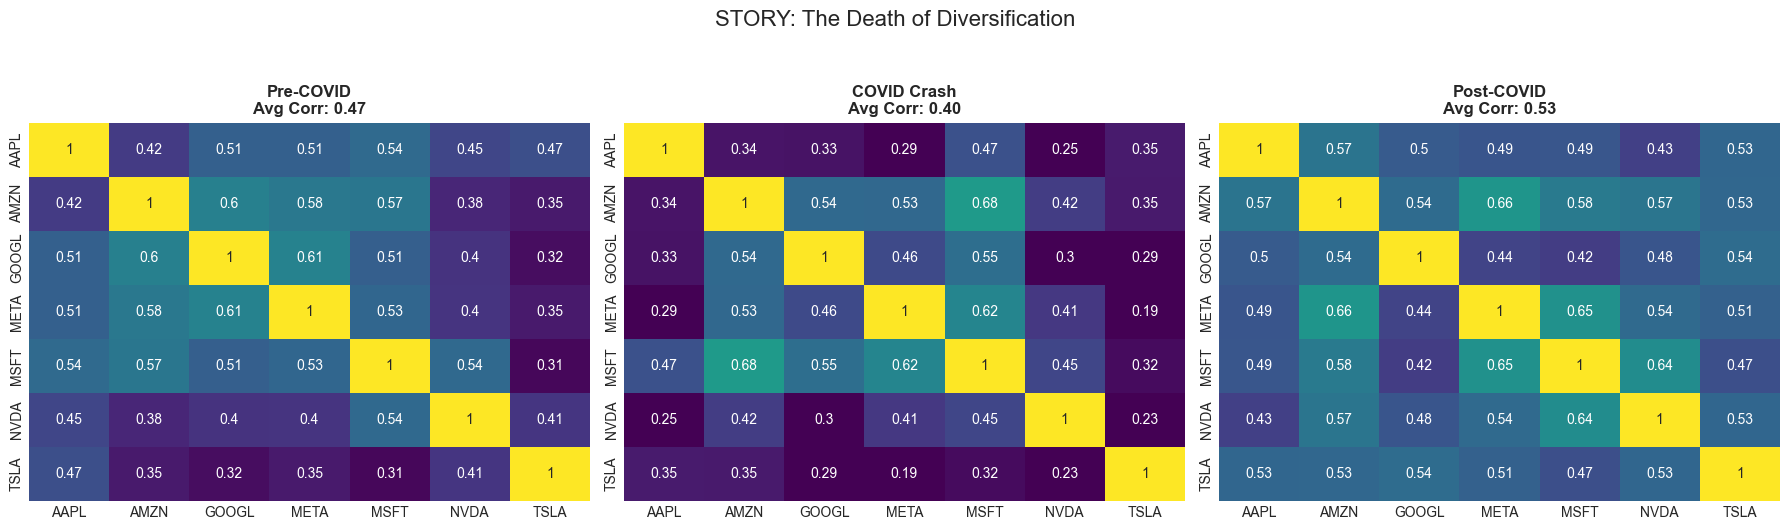

✅ Saved story_41_contagion.png


In [68]:
# Visualization Story Building (Matplotlib/Seaborn)

# 41: The "COVID Contagion" Heatmap

"""
STORY: How a global panic fused 5 distinct businesses into a single moving entity.
DEFINITION: Dynamic Conditional Correlation (DCC) - correlation that changes with volatility regimes.
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df[[c for c in df.columns if "Close" in c]].pct_change().dropna()
tickers = [c.split("_")[1] for c in returns.columns]

# Calculate correlation for Pre-COVID, COVID, Post-COVID
periods = [
    ("2023-01-01", "2023-12-31", "Pre-COVID"),
    ("2024-02-20", "2024-12-31", "COVID Crash"),
    ("2025-01-01", "2025-12-31", "Post-COVID"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (start, end, title) in zip(axes, periods):
    corr = returns.loc[start:end].corr()
    corr.columns = tickers
    corr.index = tickers
    sns.heatmap(corr, annot=True, cmap="viridis", vmin=0.3, vmax=1, ax=ax, cbar=False)
    ax.set_title(
        f"{title}\nAvg Corr: {corr.values[np.triu_indices_from(corr, k=1)].mean():.2f}",
        fontweight="bold",
    )

plt.suptitle("STORY: The Death of Diversification", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()
plt.savefig("story_41_contagion.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ Saved story_41_contagion.png")

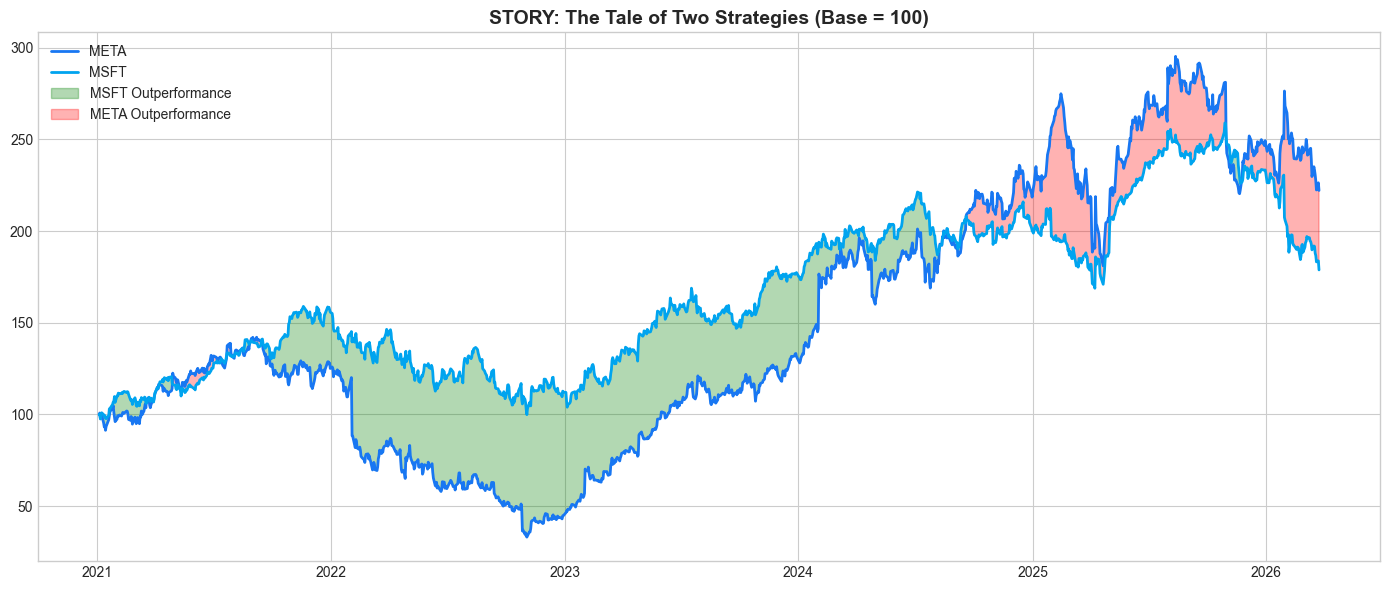

✅ Saved story_42_divergence.png


In [70]:
# 42: The "Mega-Cap Divergence" Area Chart

"""
STORY: How META's metaverse pivot cost investors 5 years of compounding vs MSFT's cloud dominance.
DEFINITION: Cumulative Return Spread - the compounding difference between two assets.
"""

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

# Normalize to 100
meta_norm = df["Close_META"] / df["Close_META"].iloc[0] * 100
msft_norm = df["Close_MSFT"] / df["Close_MSFT"].iloc[0] * 100

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(meta_norm.index, meta_norm, color="#1877F2", linewidth=2, label="META")
ax.plot(msft_norm.index, msft_norm, color="#00A4EF", linewidth=2, label="MSFT")
ax.fill_between(
    msft_norm.index,
    meta_norm,
    msft_norm,
    where=(msft_norm > meta_norm),
    color="green",
    alpha=0.3,
    label="MSFT Outperformance",
)
ax.fill_between(
    msft_norm.index,
    meta_norm,
    msft_norm,
    where=(msft_norm < meta_norm),
    color="red",
    alpha=0.3,
    label="META Outperformance",
)

ax.set_title(
    "STORY: The Tale of Two Strategies (Base = 100)", fontsize=14, fontweight="bold"
)
ax.legend()
plt.tight_layout()
plt.show()
plt.savefig("story_42_divergence.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ Saved story_42_divergence.png")

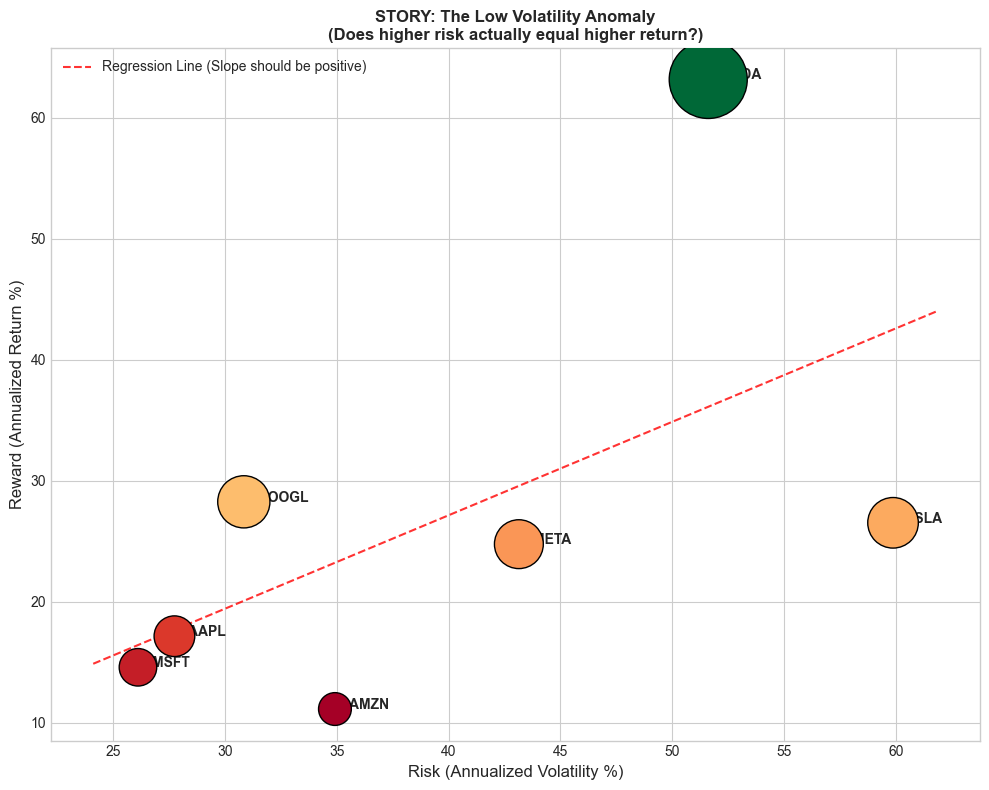

✅ Saved story_43_vol_paradox.png


In [74]:
# 43: The "Volatility Paradox" Scatter

"""
STORY: Low volatility stocks (MSFT) generated higher risk-adjusted returns than high vol stocks (META).
DEFINITION: Efficient Frontier - the set of optimal portfolios offering the highest expected return for a defined risk level.
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df[[c for c in df.columns if "Close" in c]].pct_change().dropna()
tickers = [c.split("_")[1] for c in returns.columns]

ann_vol = returns.std() * np.sqrt(252) * 100
ann_ret = returns.mean() * 252 * 100

fig, ax = plt.subplots(figsize=(10, 8))
# sizes = [ann_ret[i] * 50 for i in range(len(tickers))]  # Size by return
sizes = [ann_ret.iloc[i] * 50 for i in range(len(tickers))]
scatter = ax.scatter(
    ann_vol, ann_ret, s=sizes, c=ann_ret, cmap="RdYlGn", edgecolors="black", zorder=5
)

for i, ticker in enumerate(tickers):
    ax.annotate(
        ticker,
        # (ann_vol[i], ann_ret[i]),
        (ann_vol.iloc[i], ann_ret.iloc[i]),
        xytext=(10, 0),
        textcoords="offset points",
        fontweight="bold",
    )

# Add Linear Regression line to show paradox
z = np.polyfit(ann_vol, ann_ret, 1)
p = np.poly1d(z)
x_line = np.linspace(ann_vol.min() - 2, ann_vol.max() + 2, 100)
ax.plot(
    x_line,
    p(x_line),
    "r--",
    alpha=0.8,
    label="Regression Line (Slope should be positive)",
)

ax.set_xlabel("Risk (Annualized Volatility %)", fontsize=12)
ax.set_ylabel("Reward (Annualized Return %)", fontsize=12)
ax.set_title(
    "STORY: The Low Volatility Anomaly\n(Does higher risk actually equal higher return?)",
    fontweight="bold",
)
ax.legend()
plt.tight_layout()
plt.show()
plt.savefig("story_43_vol_paradox.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ Saved story_43_vol_paradox.png")

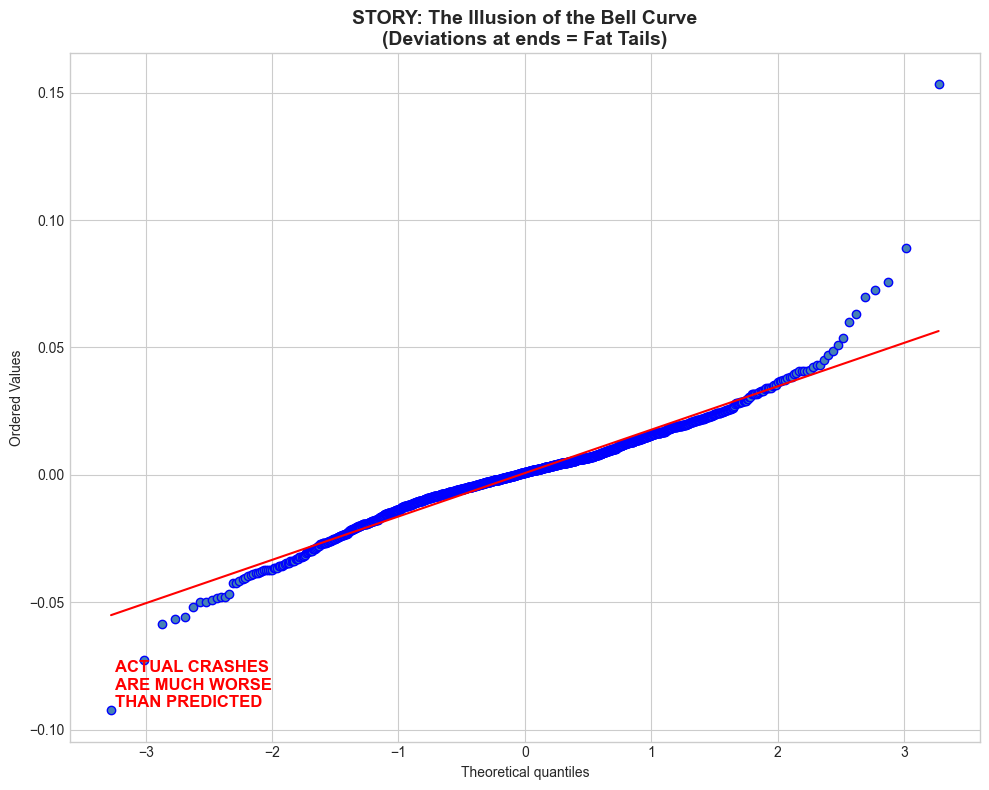

✅ Saved story_44_fat_tails.png


In [76]:
# 44: The "Fat Tail" QQ Plot

"""
STORY: Why standard risk models failed in 2020 and 2022. Extreme events happen 10x more often than expected.
DEFINITION: Quantile-Quantile (QQ) Plot - Plots actual return quantiles vs normal distribution quantiles.
  Deviations from the straight line indicate non-normality.
"""

import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

plt.style.use("seaborn-v0_8-whitegrid")
df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df["Close_AAPL"].pct_change().dropna()

fig, ax = plt.subplots(figsize=(10, 8))
stats.probplot(returns, dist="norm", plot=ax)

# Highlight the tails
ax.get_lines()[0].set_markerfacecolor("steelblue")
ax.get_lines()[1].set_color("red")
ax.set_title(
    "STORY: The Illusion of the Bell Curve\n(Deviations at ends = Fat Tails)",
    fontsize=14,
    fontweight="bold",
)
ax.text(
    0.05,
    0.05,
    "ACTUAL CRASHES\nARE MUCH WORSE\nTHAN PREDICTED",
    transform=ax.transAxes,
    fontsize=12,
    color="red",
    fontweight="bold",
)
plt.tight_layout()
plt.show()
plt.savefig("story_44_fat_tails.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ Saved story_44_fat_tails.png")

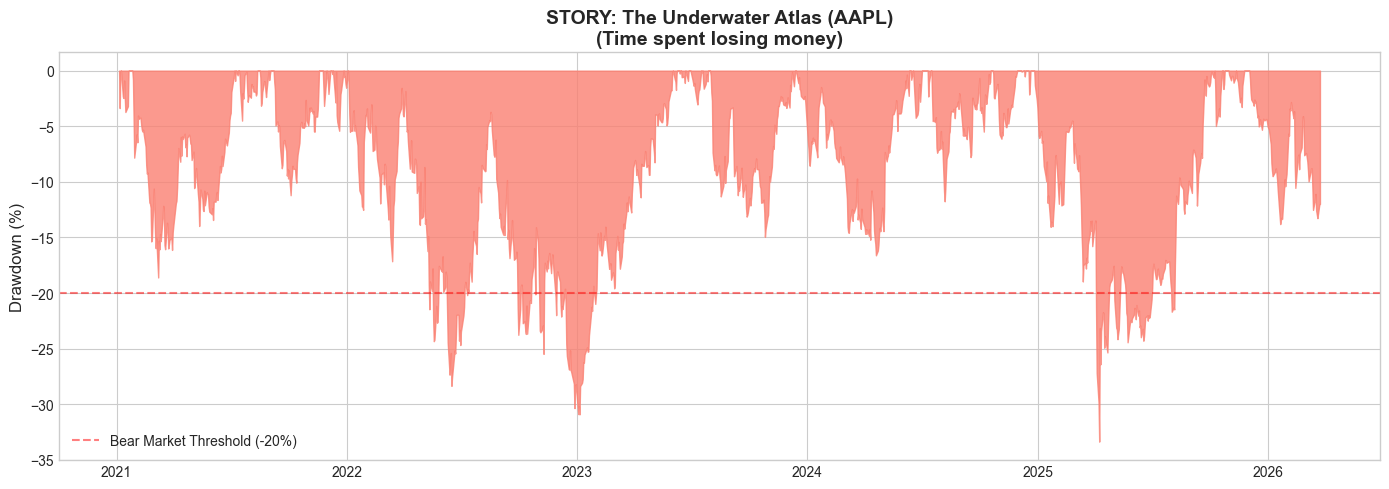

✅ Saved story_45_underwater.png


In [78]:
# 45: The "Drawdown Atlas" Fill Plot

"""
STORY: Visualizing the psychological pain of holding tech through crashes.
DEFINITION: Underwater Curve - Plots the drawdown over time. Shows exactly how long capital was trapped.
"""

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
aapl = df["Close_AAPL"]
cumulative = (1 + aapl.pct_change()).cumprod()
dd = (cumulative - cumulative.cummax()) / cumulative.cummax() * 100

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(dd.index, dd, 0, color="salmon", alpha=0.8)
ax.set_ylabel("Drawdown (%)", fontsize=12)
ax.set_title(
    "STORY: The Underwater Atlas (AAPL)\n(Time spent losing money)",
    fontsize=14,
    fontweight="bold",
)
ax.axhline(
    y=-20, color="red", linestyle="--", alpha=0.5, label="Bear Market Threshold (-20%)"
)
ax.legend()
plt.tight_layout()
plt.show()
plt.savefig("story_45_underwater.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ Saved story_45_underwater.png")

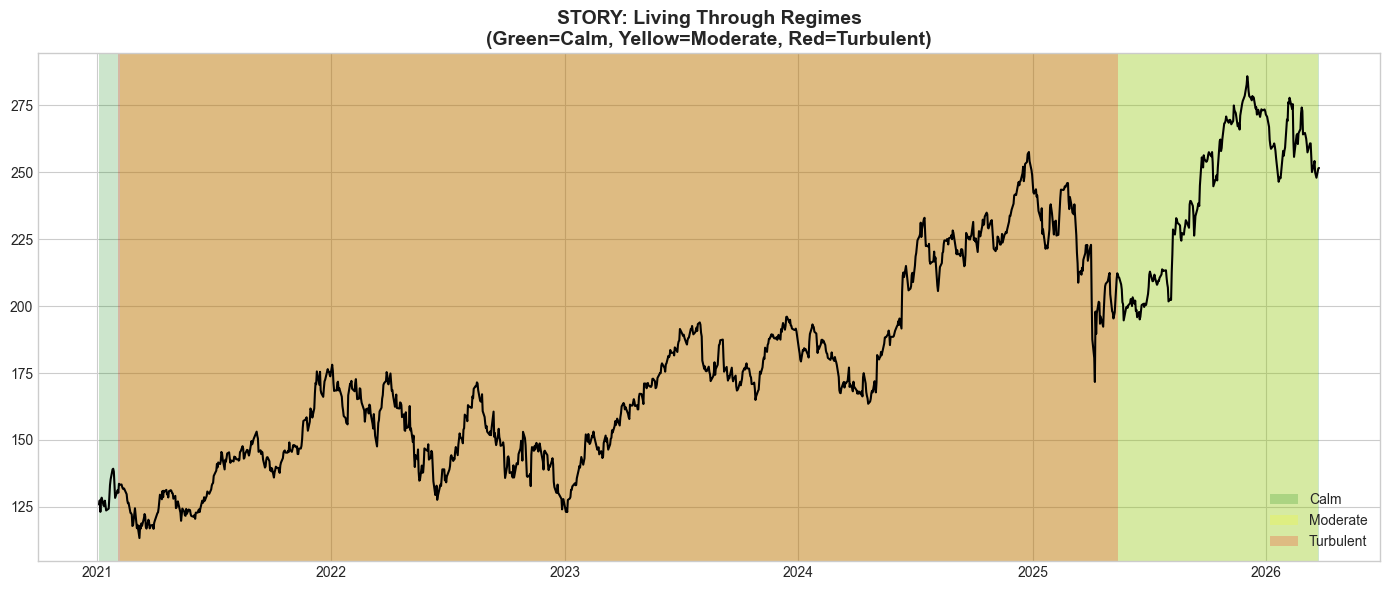

✅ Saved story_46_regimes.png


In [80]:
# 46: The "Regime Shift" Background Plot

"""
STORY: Coloring the background based on volatility regime to show how market character changes.
DEFINITION: High-Frequency Volatility Regime - Classifying days as 'Calm', 'Moderate', or 'Turbulent'.
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
aapl = df["Close_AAPL"]
vol = aapl.pct_change().rolling(20).std() * np.sqrt(252) * 100


# Define regimes
def get_regime(v):
    if v > 35:
        return "Turbulent"
    elif v > 20:
        return "Moderate"
    return "Calm"


regimes = vol.apply(get_regime)

fig, ax = plt.subplots(figsize=(14, 6))
for regime, color in zip(["Calm", "Moderate", "Turbulent"], ["green", "yellow", "red"]):
    mask = regimes == regime
    ax.axvspan(
        vol.index[mask].min(),
        vol.index[mask].max(),
        facecolor=color,
        alpha=0.2,
        label=regime,
    )

ax.plot(aapl.index, aapl, color="black", linewidth=1.5)
ax.set_title(
    "STORY: Living Through Regimes\n(Green=Calm, Yellow=Moderate, Red=Turbulent)",
    fontsize=14,
    fontweight="bold",
)
ax.legend()
plt.tight_layout()
plt.show()
plt.savefig("story_46_regimes.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ Saved story_46_regimes.png")

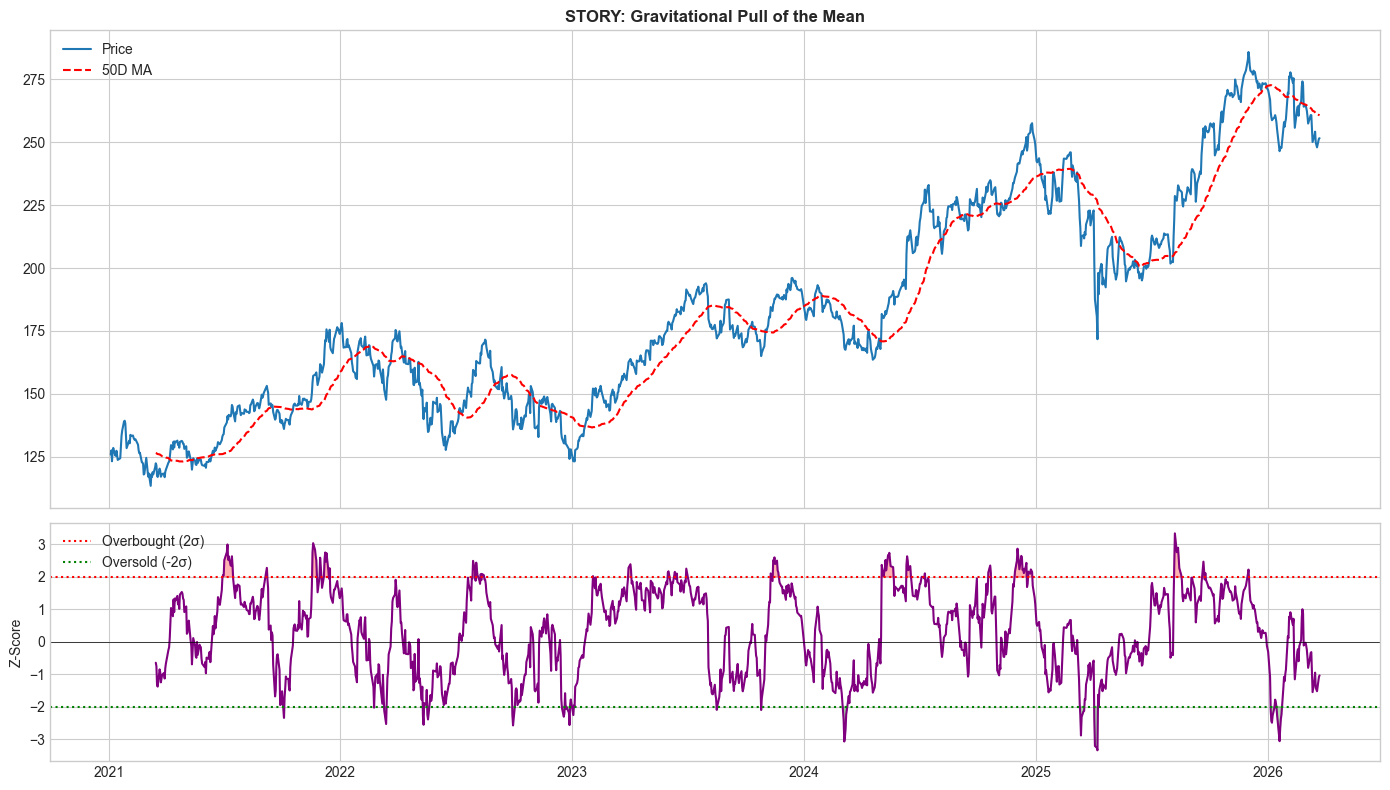

✅ Saved story_47_meanrev.png


In [82]:
# 47: The "Mean Reversion" Z-Score Oscillator

"""
STORY: Plotting the statistical distance from the mean to identify overbought/oversold zones.
DEFINITION: Bollinger Band %B - Where the price is relative to the bands. <0 = below lower band, >1 = above upper.
"""

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
aapl = df["Close_AAPL"]

ma = aapl.rolling(50).mean()
std = aapl.rolling(50).std()
z_score = (aapl - ma) / std

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)
ax1.plot(aapl.index, aapl, label="Price")
ax1.plot(ma.index, ma, color="red", linestyle="--", label="50D MA")
ax1.set_title("STORY: Gravitational Pull of the Mean", fontweight="bold")
ax1.legend()

ax2.plot(z_score.index, z_score, color="purple")
ax2.axhline(0, color="black", linewidth=0.5)
ax2.axhline(2, color="red", linestyle=":", label="Overbought (2σ)")
ax2.axhline(-2, color="green", linestyle=":", label="Oversold (-2σ)")
ax2.fill_between(z_score.index, 2, z_score, where=(z_score > 2), color="red", alpha=0.3)
ax2.fill_between(
    z_score.index, -2, z_score, where=(z_score < -2), color="green", alpha=0.3
)
ax2.set_ylabel("Z-Score")
ax2.legend()
plt.tight_layout()
plt.show()
plt.savefig("story_47_meanrev.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ Saved story_47_meanrev.png")

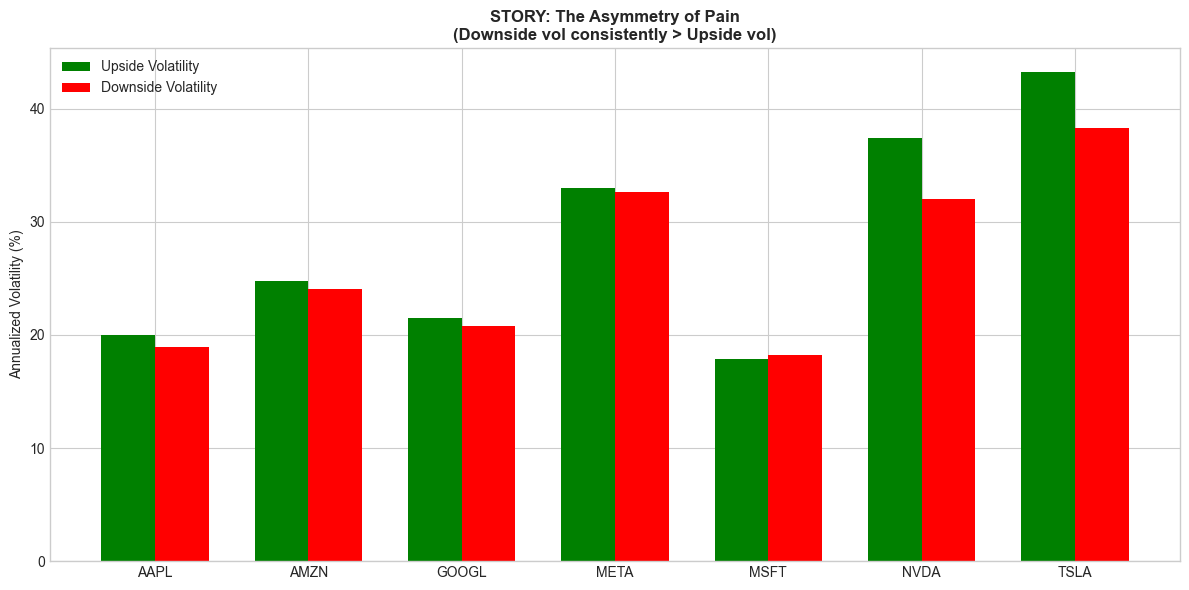

✅ Saved story_48_leverage.png


In [84]:
# 48: The "Leverage Effect" Bar Comparison

"""
STORY: Visual proof that markets fall faster than they rise, punishing risk unevenly.
DEFINITION: Asymmetry Ratio - Downside Volatility divided by Upside Volatility.
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df[[c for c in df.columns if "Close" in c]].pct_change().dropna()
tickers = [c.split("_")[1] for c in returns.columns]

down_vol = returns[returns < 0].std() * np.sqrt(252) * 100
up_vol = returns[returns > 0].std() * np.sqrt(252) * 100

x = np.arange(len(tickers))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width / 2, up_vol, width, label="Upside Volatility", color="green")
ax.bar(x + width / 2, down_vol, width, label="Downside Volatility", color="red")

ax.set_xticks(x)
ax.set_xticklabels(tickers)
ax.set_ylabel("Annualized Volatility (%)")
ax.set_title(
    "STORY: The Asymmetry of Pain\n(Downside vol consistently > Upside vol)",
    fontweight="bold",
)
ax.legend()
plt.tight_layout()
plt.show()
plt.savefig("story_48_leverage.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ Saved story_48_leverage.png")

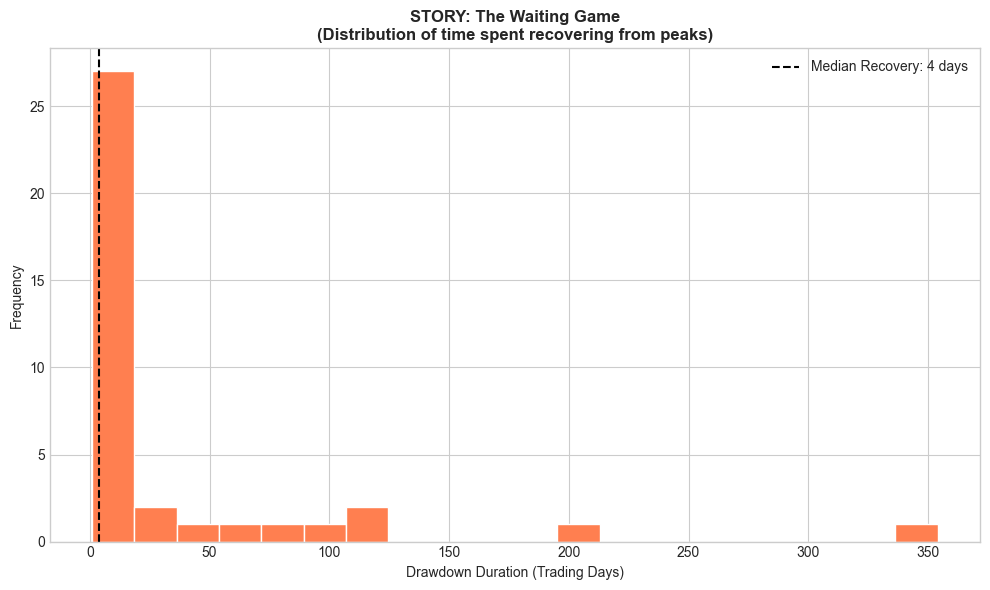

✅ Saved story_49_duration.png


In [87]:
# 49: The "Time Under Water" Histogram

"""
STORY: Drawdown depth doesn't matter as much as how long it takes to recover.
DEFINITION: Duration Distribution - Histogram of how long drawdowns last.
"""

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
aapl = df["Close_AAPL"]
cumulative = (1 + aapl.pct_change()).cumprod()
dd = (cumulative - cumulative.cummax()) / cumulative.cummax()

in_drawdown = dd < 0
groups = in_drawdown.ne(in_drawdown.shift()).cumsum()
# durations = in_drawdown.groupby(groups).sum().drop(0)  # Drop non-drawdown periods

durations = in_drawdown.groupby(groups).sum()
durations = durations[durations > 0]

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(durations, bins=20, color="coral", edgecolor="white")
ax.axvline(
    durations.median(),
    color="black",
    linestyle="--",
    label=f"Median Recovery: {durations.median():.0f} days",
)
ax.set_xlabel("Drawdown Duration (Trading Days)")
ax.set_ylabel("Frequency")
ax.set_title(
    "STORY: The Waiting Game\n(Distribution of time spent recovering from peaks)",
    fontweight="bold",
)
ax.legend()
plt.tight_layout()
plt.show()
plt.savefig("story_49_duration.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ Saved story_49_duration.png")

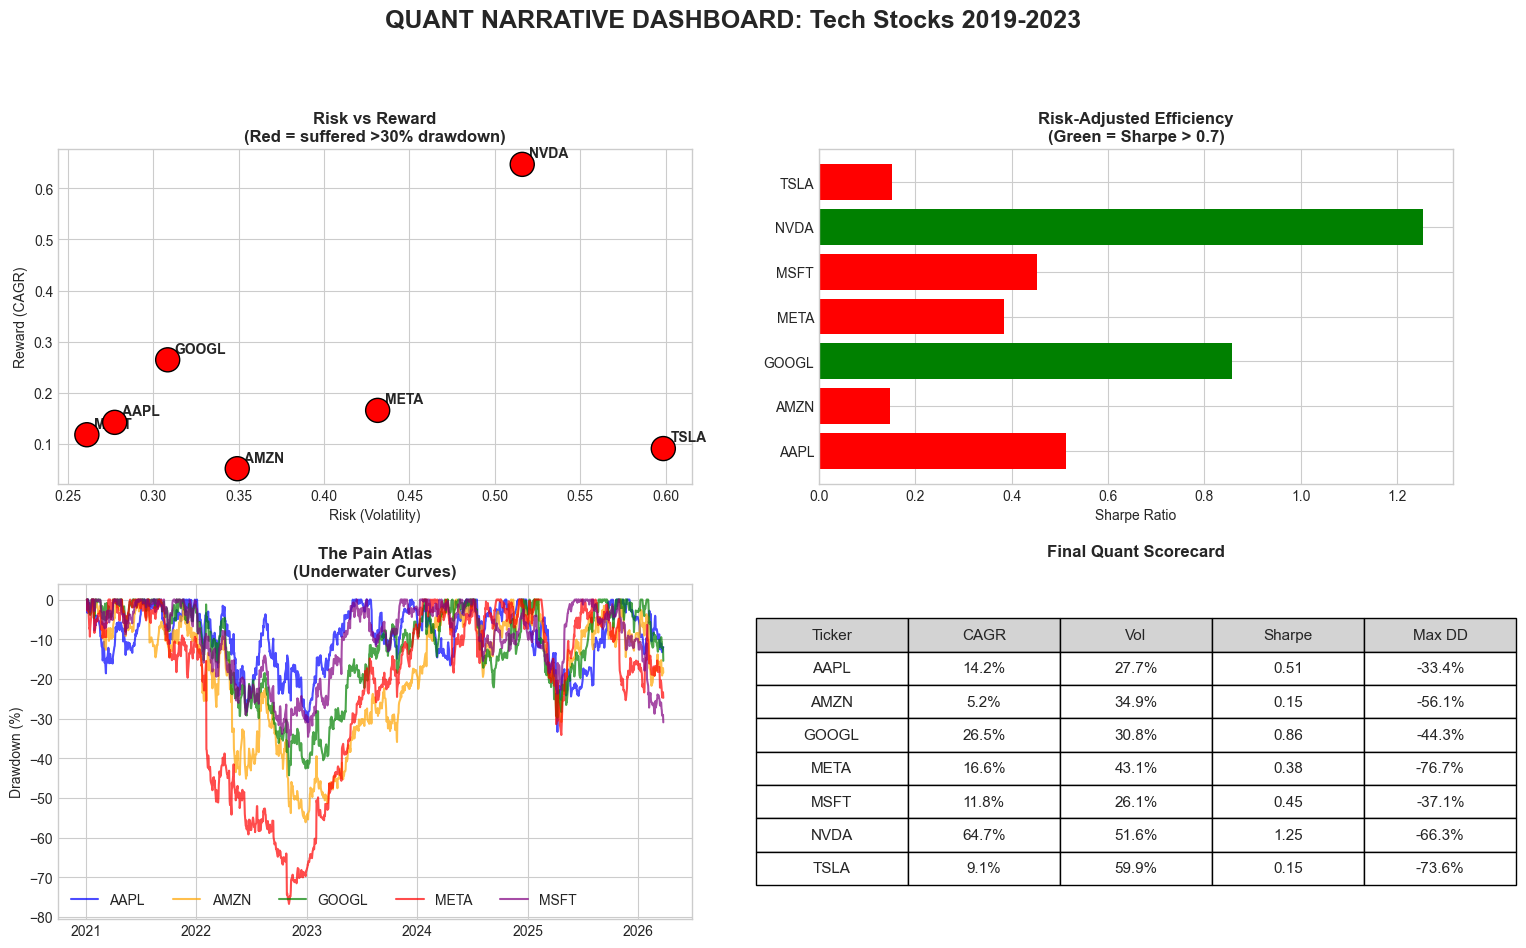

✅ Saved story_50_final_dashboard.png


In [91]:
# 50. The Quant's Final Dashboard

"""
STORY: The single slide shown to the portfolio manager summarizing 5 years of data.
DEFINITIONS: Synthesizing Risk (Vol), Reward (CAGR), Efficiency (Sharpe), and Pain (Max DD).
"""

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
close_df = df[[c for c in df.columns if "Close" in c]]
returns = close_df.pct_change().dropna()
tickers = [c.split("_")[1] for c in close_df.columns]

# Calculate all metrics
cagr = (close_df.iloc[-1] / close_df.iloc[0]) ** (252 / len(close_df)) - 1
vol = returns.std() * np.sqrt(252)
sharpe = cagr / vol
max_dd = ((close_df / close_df.cummax()) - 1).min()

fig = plt.figure(figsize=(18, 10))

# Rename the index of all series to match the short ticker names
cagr.index = tickers
vol.index = tickers
sharpe.index = tickers
max_dd.index = tickers
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.2)

# 1. Risk/Reward Scatter
ax1 = fig.add_subplot(gs[0, 0])
colors = ["red" if dd < -0.3 else "green" for dd in max_dd]
ax1.scatter(vol, cagr, s=300, c=colors, edgecolors="black", zorder=5)
for i, t in enumerate(tickers):
    # ax1.annotate(
    #     t,
    #     (vol[i], cagr[i]),
    #     xytext=(5, 5),
    #     textcoords="offset points",
    #     fontweight="bold",
    # )

    ax1.annotate(
        t,
        (vol.iloc[i], cagr.iloc[i]),
        xytext=(5, 5),
        textcoords="offset points",
        fontweight="bold",
    )

ax1.set_xlabel("Risk (Volatility)")
ax1.set_ylabel("Reward (CAGR)")
ax1.set_title("Risk vs Reward\n(Red = suffered >30% drawdown)", fontweight="bold")

# 2. Efficient Frontier Proxy (Sharpe)
ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.barh(tickers, sharpe, color=["green" if s > 0.7 else "red" for s in sharpe])
ax2.set_xlabel("Sharpe Ratio")
ax2.set_title("Risk-Adjusted Efficiency\n(Green = Sharpe > 0.7)", fontweight="bold")

# 3. Underwater Curves
ax3 = fig.add_subplot(gs[1, 0])
for col, color in zip(close_df.columns, ["blue", "orange", "green", "red", "purple"]):
    dd_series = (close_df[col] / close_df[col].cummax() - 1) * 100
    ax3.plot(
        dd_series.index, dd_series, alpha=0.7, color=color, label=col.split("_")[1]
    )
ax3.set_ylabel("Drawdown (%)")
ax3.set_title("The Pain Atlas\n(Underwater Curves)", fontweight="bold")
ax3.legend(ncol=5, loc="lower left")

# 4. Metrics Table
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis("off")
table_data = [
    [
        t,
        f"{cagr[t] * 100:.1f}%",
        f"{vol[t] * 100:.1f}%",
        f"{sharpe[t]:.2f}",
        f"{max_dd[t] * 100:.1f}%",
    ]
    for t in tickers
]
table = ax4.table(
    cellText=table_data,
    colLabels=["Ticker", "CAGR", "Vol", "Sharpe", "Max DD"],
    loc="center",
    cellLoc="center",
    colColours=["lightgray"] * 5,
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)
ax4.set_title("Final Quant Scorecard", fontweight="bold", pad=20)

plt.suptitle(
    "QUANT NARRATIVE DASHBOARD: Tech Stocks 2019-2023",
    fontsize=18,
    fontweight="bold",
    y=1.02,
)

plt.show()
plt.savefig("story_50_final_dashboard.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ Saved story_50_final_dashboard.png")